# Zero-Noise Grid Search

## DDM with Zero Noise

The point of this notebook is to confirm that my existing grid search method can recover data. To simplify the situation, we will create a zero-noise model.

In [ ]:
import pandas as pd
import numpy as np
import pyddm

N = 200  # number of trials

true_drift = 0.5
true_noise = 0.0

# No noise → deterministic RT = B / drift
true_rt = 1 / true_drift  # = 2.0 seconds

df = pd.DataFrame({
    "RT": np.ones(N) * true_rt,
    "choice": np.array([1] * N),
})

sample = pyddm.Sample.from_pandas_dataframe(
    df,
    choice_column_name="choice",
    rt_column_name="RT",
    choice_names=("left", "right")
)

TypeError: Sample.from_pandas_dataframe() got an unexpected keyword argument 'conditions'

In [2]:
from pyddm.models.loss import LossLikelihood

drift_grid = np.linspace(-1, 1, 21)
noise_val = 0.0  # fixed

results = []

def toy_drift(x, t, drift):
    return np.ones_like(x) * drift

def toy_noise(x, t, noise):
    return np.ones_like(x) * noise

for d in drift_grid:
    m = pyddm.gddm(
        drift=toy_drift,
        noise=toy_noise,
        parameters={"drift": d, "noise": noise_val},
        conditions=[],
        choice_names=("left", "right"),
        T_dur=5,
        dx=0.01,
        dt=0.001
    )

    lossfunc = LossLikelihood(sample=sample, model=m,dt=m.dt, T_dur=m.T_dur)
    nll = lossfunc.loss(m) # Temporariliy muted logger warnings in solution.py line 354
    # print(f"drift={d:.3f}, NLL={nll:.3f}")
    results.append({"drift": d, "nll": nll})

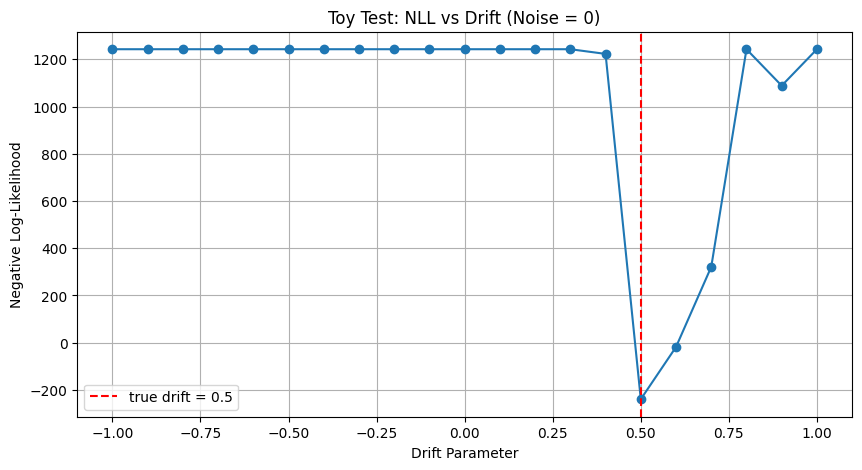

In [3]:
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.plot(results_df["drift"], results_df["nll"], marker="o")
plt.axvline(true_drift, color="red", linestyle="--",
            label=f"true drift = {true_drift}")
plt.title("Toy Test: NLL vs Drift (Noise = 0)")
plt.xlabel("Drift Parameter")
plt.ylabel("Negative Log-Likelihood")
plt.legend()
plt.grid(True)
plt.show()

## ADDM with Zero Noise

We need a helper function to calculate true_RT.

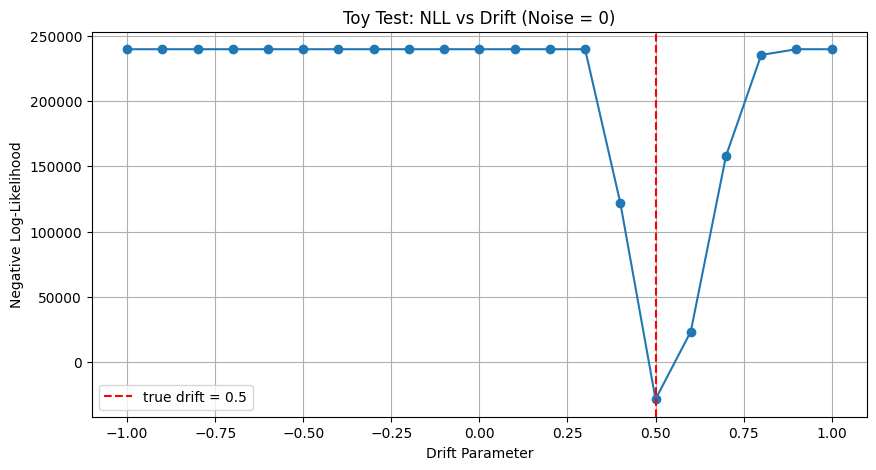

In [92]:
N = 200  # number of trials

true_drift = 0.5
true_noise = 0

# Deterministic RT (still placeholder)
dt = 0.01
true_rt = 3.2 # Manually calculated

rows = []

for trial in range(N):
    fixations = [1, 2, 1]          # as stated above
    durations = [0.2, 0.6, 1.4]    # as stated above

    for _ in range(N):
        rows.append({
            "RT": true_rt,
            "choice": 1,                # deterministic choice: left
            "fixation": tuple([1] * int(0.2 / dt) + [2] * int(0.6 / dt) + [1] * int(1.4 / dt))
        })

df = pd.DataFrame(rows)

sample = pyddm.Sample.from_pandas_dataframe(
    df,
    rt_column_name="RT",
    choice_column_name="choice",
    choice_names=("left", "right"),
)

drift_grid = np.linspace(-1, 1, 21)
noise_val = 0  # fixed

# Modified drift function with theta = 0 and avgWTP_left = avgWTP_right = 1
def drift_function(x, t, d, fixation):
    idx = min(int(t / dt), len(fixation) - 1)
    f = fixation[idx]
    if f == 0:   # no fixation
        drift_val =  0
    elif f == 1:
        drift_val = d
    else:
        drift_val = -d
    
    return np.ones_like(x) * drift_val

def noise_function(x, t, noise):
    return np.ones_like(x) * noise

results = []

for d in drift_grid:
    m = pyddm.gddm(
            drift=drift_function,
            noise=noise_function,
            parameters={"d": d, "noise": noise_val},
            conditions=["fixation"],
            choice_names=("left","right"),
            T_dur=4,
            dx=0.01,
            dt=dt
    )

    lossfunc = LossLikelihood(sample=sample, model=m,dt=m.dt, T_dur=m.T_dur)
    nll = lossfunc.loss(m) # Temporariliy muted logger warnings in solution.py line 354
    # print(f"drift={d:.3f}, NLL={nll:.3f}")
    results.append({"drift": d, "nll": nll})

results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.plot(results_df["drift"], results_df["nll"], marker="o")
plt.axvline(true_drift, color="red", linestyle="--",
            label=f"true drift = {true_drift}")
plt.title("Toy Test: NLL vs Drift (Noise = 0)")
plt.xlabel("Drift Parameter")
plt.ylabel("Negative Log-Likelihood")
plt.legend()
plt.grid(True)
plt.show()

HUGE NOTE!!!! Calculate correct RT's and true drift values T_T. For the above fixation condition: 
$RT = 1.2 + \frac{1}{d}$

My suspicion as to why PyDDM is not estimating the correct parameters is because noise affects the way that data is clipped. This is the non-unique unidentifiable part of the pipeline.